In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# СЧИТЫВАЕМ данные

In [7]:
orders_xlsx = pd.read_excel('/Users/vladislavlipkin/Documents/PycharmProjects/Simulate/final_python_samokat/data/orders.xlsx')

In [8]:
products_xlsx = pd.read_excel('/Users/vladislavlipkin/Documents/PycharmProjects/Simulate/final_python_samokat/data/products.xlsx')

# и что же там ?

In [9]:
orders_xlsx.head(5)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


In [10]:
products_xlsx.head(5)

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


# Описание таблиц

## Таблица products

| Колонка       | Описание                    |
|---------------|-----------------------------|
| product_id    | id товара                   |
| level1        | категория                   |
| level2        | подкатегория                |
| name          | наименование товара         |

## Таблица orders

| Колонка        | Описание                         |
|----------------|----------------------------------|
| order_id       | номер чека                       |
| accepted_at    | дата и время чека                |
| product_id     | id товара                        |
| quantity       | кол-во товара в чеке             |
| regular_price  | регулярная цена                  |
| price          | текущая цена                     |
| cost_price     | закупочная цена                  |

# TASKS

# 1. Самая ходовая товарная группа

## Задание
По какой категории товаров продано больше всего позиций?

## Требования
1. Подкрепите ответ таблицей, в которой рассчитано количество проданных штук товара в каждой товарной категории.
2. Дополнительно постройте на основании этой таблицы barchart.
3. Проверьте, чтобы все подписи на графике выглядели читаемо и понятно.
4. График должен быть сходу понятен стороннему наблюдателю.

In [13]:
merge_table = pd.merge(
    orders_xlsx
    , products_xlsx
    , on='product_id'
    , how='left'
)

In [14]:
merge_table.head(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан


In [32]:
agg_count_category = merge_table.groupby('level1').agg(
    quantity_of_products = ('quantity', 'sum')
).reset_index()

result_quantity_of_products = agg_count_category.sort_values('quantity_of_products', ascending=False).head(5)
result_quantity_of_products

,level1,quantity_of_products
1,Безалкогольные напитки,534
11,Молочная продукция,483
19,Свежие овощи,262
10,Кулинария,250
0,Бакалея,239


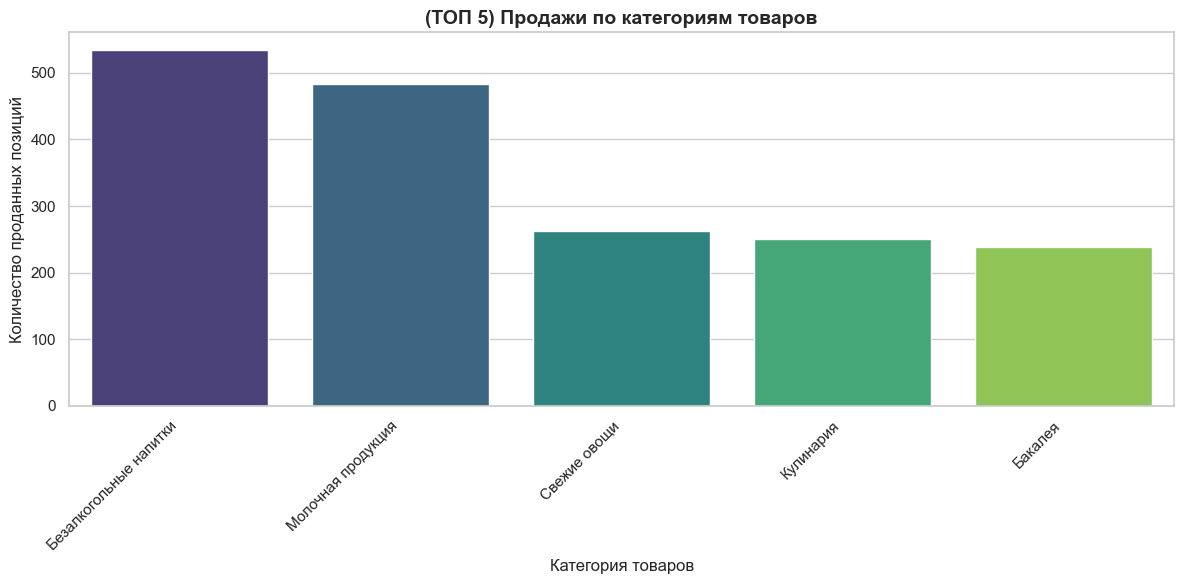

In [42]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x='level1', y='quantity_of_products', data=result_quantity_of_products, palette='viridis')
plt.xlabel('Категория товаров', fontsize=12)
plt.ylabel('Количество проданных позиций', fontsize=12)
plt.title('(ТОП 5) Продажи по категориям товаров', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()